# 45. Divided Differences

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. State the **recursion** that defines divided differences and prove it correct.
2. Prove the **four properties**: symmetry, leading coefficient, linearity and the derivative
   connection.
3. Compute a divided difference three independent ways and check them against each other.
4. Measure where the accuracy goes, and find the order at which these become worthless.
5. Take the **confluent limit** and see Taylor's coefficients fall out of it.
6. Say why the rest of Part 7 keeps the order low, from evidence rather than from taste.

## Prerequisites

Lesson 44 (the Newton form, whose coefficients these are). Lesson 4 (cancellation, which is the
whole story of section 6). Lesson 2 (the Taylor series, which section 5 rederives as a limit).

---

## 1. The definition

Divided differences are defined by a recursion on the number of nodes:

$$
f[x_i] = f(x_i), \qquad
f[x_i, \dots, x_{i+k}] = \frac{f[x_{i+1}, \dots, x_{i+k}] - f[x_i, \dots, x_{i+k-1}]}
                              {x_{i+k} - x_i}
$$

Laying them out gives the **divided difference table**, whose top row is exactly the coefficient
vector of lesson 44's Newton form.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import divdiff as dd

nodes = np.array([0.0, 0.5, 1.0, 2.0])
values = np.array([1.0, 1.6487, 2.7183, 7.3891])

table = dd.table(nodes, values)
print("the divided difference table, with unreachable entries left as nan:")
header = "      x        f[.]      f[.,.]    f[.,.,.]  f[.,.,.,.]"
print(header)
for i in range(nodes.size):
    row = "  ".join("        " if not np.isfinite(v) else f"{v:10.6f}" for v in table[i])
    print(f"{nodes[i]:7.2f}  {row}")
print()
print("the top row is the Newton coefficient vector:")
print(" ", np.array2string(dd.coefficients(nodes, values), precision=6))

the divided difference table, with unreachable entries left as nan:
      x        f[.]      f[.,.]    f[.,.,.]  f[.,.,.,.]
   0.00    1.000000    1.297400    0.841800    0.422967
   0.50    1.648700    2.139200    1.687733          
   1.00    2.718300    4.670800                    
   2.00    7.389100                              

the top row is the Newton coefficient vector:
  [1.       1.2974   0.8418   0.422967]


The unreachable entries are nan on purpose. An entry above the anti-diagonal was never computed,
and a caller who reads one by mistake should get a nan rather than a plausible zero.

## 2. Three routes to the same number

The recursion is one way to compute $f[x_0, \dots, x_k]$. There is also a closed form:

$$
f[x_0, \dots, x_k] = \sum_i \frac{f(x_i)}{\prod_{j\ne i}(x_i - x_j)}
$$

and there is the naive recursive evaluation, which is exponential and written only for checking.
Three independent computations is what makes agreement evidence rather than a tautology.

In [3]:
print(f"{'k':>4}{'table':>20}{'recursion':>20}{'closed form':>20}")
for k in (1, 2, 4, 6, 8):
    g = np.random.default_rng(k)
    xs = np.sort(g.uniform(-1.0, 1.0, k + 1))
    ys = g.standard_normal(k + 1)
    a = float(dd.coefficients(xs, ys)[-1])
    b = dd.recursive(xs, ys)
    c = dd.from_definition(xs, ys)
    print(f"{k:>4}{a:>20.12e}{b:>20.12e}{c:>20.12e}")
    scale = max(abs(a), abs(c), 1e-300)
    assert abs(a - b) / scale < 1e-9 and abs(a - c) / scale < 1e-9

   k               table           recursion         closed form
   1 -1.862103994874e+00 -1.862103994874e+00 -1.862103994874e+00
   2 -5.260162218140e+01 -5.260162218140e+01 -5.260162218140e+01
   4  3.337887538990e+01  3.337887538990e+01  3.337887538990e+01
   6  1.139100630875e+04  1.139100630875e+04  1.139100630875e+04
   8 -8.874264768796e+03 -8.874264768796e+03 -8.874264768796e+03


The closed form is also the quickest proof of the first property.

## 3. Symmetry

**A divided difference does not depend on the order of its arguments**, even though the recursion
that computes it plainly does.

The closed form makes it obvious: $\sum_i f(x_i) / \prod_{j\ne i}(x_i - x_j)$ is visibly
symmetric, since permuting the nodes permutes the terms of a sum. The recursion is not symmetric
at all, and that mismatch is worth holding onto: **the value is symmetric, the computation is
not**, and in floating point the computation is what you get.

In [4]:
print("relative spread of f[x_0,...,x_k] across 21 orderings of the same nodes,")
print("equally spaced on [0, 1], f = exp:")
print(f"{'k':>5}{'relative spread':>20}")
for n in (3, 5, 8, 11, 14, 17):
    xs = np.linspace(0.0, 1.0, n)
    out = dd.symmetry_report(xs, np.exp(xs), n_orders=20, rng=np.random.default_rng(7))
    print(f"{n - 1:>5}{out['relative_spread']:>20.2e}")
    assert (out["relative_spread"] < 1e-10) if n <= 5 else True
    assert (out["relative_spread"] > 1e-2) if n >= 14 else True

relative spread of f[x_0,...,x_k] across 21 orderings of the same nodes,
equally spaced on [0, 1], f = exp:
    k     relative spread
    2            0.00e+00
    4            1.63e-13
    7            8.15e-09
   10            9.01e-04
   13            1.91e+00
   16            1.93e+00


**By order 13 the answer depends on the ordering by 191 percent.** It carries no information at
all. The nodes are equally spaced, so this is not node clustering: it is the recursion's own
cancellation, and section 6 measures where it comes from.

That single table is the reason the rest of Part 7 never uses a high order divided difference.

## 4. The other three properties

**It is the leading coefficient.** $f[x_0, \dots, x_k]$ is the coefficient of $x^k$ in the
interpolating polynomial through those $k+1$ points. That is why the Newton form works at all: the
last term supplies exactly the leading behaviour the earlier terms are missing.

In [5]:
print(f"{'n':>5}{'divided difference':>22}{'leading coefficient':>22}{'relative gap':>15}")
for n in (3, 6, 9, 12, 15):
    xs = np.linspace(-1.0, 1.0, n)
    out = dd.is_leading_coefficient(xs, np.cos(2.0 * xs))
    print(f"{n:>5}{out['divided_difference']:>22.10e}"
          f"{out['leading_coefficient']:>22.10e}{out['relative_gap']:>15.2e}")
    assert out["relative_gap"] < 1e-10

    n    divided difference   leading coefficient   relative gap
    3     -1.4161468365e+00     -1.4161468365e+00       0.00e+00
    6      6.1062266354e-16      0.0000000000e+00       3.14e-16
    9      5.8405337259e-03      5.8405337259e-03       1.25e-15
   12     -4.4200483117e-15      8.3714170962e-14       4.46e-14
   15     -1.7918942961e-07     -1.7918100186e-07       4.23e-12


Note the $n = 6$ and $n = 12$ rows, where both numbers are essentially zero. That is correct:
$\cos(2x)$ is even, the nodes are symmetric, and the leading coefficient of an odd degree
interpolant of an even function vanishes exactly. The comparison is scaled by the table rather
than by the answer, because dividing by a genuine zero would report a relative error of 1 for two
answers that agree perfectly.

**Linearity.** $f \mapsto f[x_0,\dots,x_k]$ is linear in the data, which follows from the closed
form in one line.

In [6]:
xs = np.linspace(0.0, 1.0, 7)
out = dd.linearity_report(xs, rng.standard_normal(xs.size), rng.standard_normal(xs.size))
print(f"combined against separate: {out['relative_gap']:.2e}")
assert out["relative_gap"] < 1e-9
assert out["relative_gap"] < 1e-9

combined against separate: 5.85e-16


**The derivative connection.** There is a $\xi$ in the interval with

$$
f[x_0, \dots, x_k] = \frac{f^{(k)}(\xi)}{k!}
$$

so a divided difference is a derivative in disguise, scaled by a factorial. Since $\xi$ is not
known, the checkable form is that the divided difference lies between the smallest and largest
values of $f^{(k)}/k!$ on the interval.

In [7]:
print(f"{'k':>4}{'trials':>9}{'inside the range':>19}{'range of f^(k)/k!':>26}")
for k in (1, 2, 3, 4):
    out = dd.derivative_connection(np.exp, np.exp, 0.0, 1.0, k, n_trials=40,
                                   rng=np.random.default_rng(11))
    lo, hi = out["range_of_derivative"]
    print(f"{k:>4}{out['trials']:>9}{out['inside']:>19}"
          f"{f'[{lo:.4f}, {hi:.4f}]':>26}")
    assert out["inside"] == out["trials"]

   k   trials   inside the range         range of f^(k)/k!
   1       40                 40          [1.0000, 2.7183]
   2       40                 40          [0.5000, 1.3591]
   3       40                 40          [0.1667, 0.4530]
   4       40                 40          [0.0417, 0.1133]


## 5. The confluent limit is Taylor's series

Let every node coalesce at a single point. The recursion divides by zero, but the limit exists and
is

$$
f[\underbrace{x, x, \dots, x}_{k+1}] = \frac{f^{(k)}(x)}{k!}
$$

which is the Taylor coefficient. So the Newton form with repeated nodes **is** the Taylor
polynomial, and interpolation and Taylor expansion are the two ends of one construction with the
node spacing as the parameter.

In [8]:
import math

print("crowding the nodes toward a point, f = exp at 0:")
print(f"{'h':>10}" + "".join(f"{'k=' + str(k):>13}" for k in (1, 2, 3, 4, 6)))
for h in (1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6):
    row = []
    for k in (1, 2, 3, 4, 6):
        xs = h * np.arange(k + 1)
        v = float(dd.coefficients(xs, np.exp(xs))[-1])
        target = 1.0 / math.factorial(k)
        row.append(abs(v - target) / target)
    print(f"{h:>10.0e}" + "".join(f"{v:>13.2e}" for v in row))
print()
print("the limit itself, computed from the derivatives directly:")
for k in (0, 1, 2, 3, 5):
    print(f"  k = {k}:  f[x,...,x] = {dd.confluent(0.0, np.ones(k + 1)):.10f}"
          f"   1/k! = {1.0 / math.factorial(k):.10f}")
    assert abs(dd.confluent(0.0, np.ones(k + 1)) - 1.0 / math.factorial(k)) < 1e-14

crowding the nodes toward a point, f = exp at 0:
         h          k=1          k=2          k=3          k=4          k=6
     1e-01     5.17e-02     1.06e-01     1.63e-01     2.23e-01     3.53e-01
     1e-02     5.02e-03     1.01e-02     1.51e-02     2.02e-02     2.83e-02
     1e-03     5.00e-04     1.00e-03     1.50e-03     1.87e-03     4.43e+02
     1e-04     5.00e-05     1.00e-04     8.89e-05     3.44e+00     2.89e+09
     1e-05     5.00e-06     1.12e-05     1.12e-01     2.22e+04     1.78e+15
     1e-06     5.00e-07     8.89e-05     2.23e+02     4.44e+08     6.66e+20

the limit itself, computed from the derivatives directly:
  k = 0:  f[x,...,x] = 1.0000000000   1/k! = 1.0000000000
  k = 1:  f[x,...,x] = 1.0000000000   1/k! = 1.0000000000
  k = 2:  f[x,...,x] = 0.5000000000   1/k! = 0.5000000000
  k = 3:  f[x,...,x] = 0.1666666667   1/k! = 0.1666666667
  k = 5:  f[x,...,x] = 0.0083333333   1/k! = 0.0083333333


Lesson 50's Hermite interpolation is exactly this: repeat each node as many times as you have
derivatives, and fill the confluent entries from the Taylor coefficients.

## 6. Where the accuracy goes

The table above has a **U shape** in every column, and the bottom of it moves with $k$.

Truncation falls like $h$: the divided difference approaches $f^{(k)}/k!$ as the nodes crowd.
Rounding rises like $\varepsilon/h^k$: the recursion divides by $h$ exactly $k$ times, and the
numerators are differences of nearly equal numbers. Balancing the two puts the optimum at

$$
h \approx \varepsilon^{1/(k+1)}
$$

In [9]:
eps = np.finfo(float).eps
print(f"{'k':>4}{'best h predicted':>20}{'best h measured':>19}")
measured = {2: 1e-5, 3: 1e-4, 4: 1e-3, 6: 1e-2}
for k, h_best in measured.items():
    print(f"{k:>4}{eps ** (1.0 / (k + 1)):>20.2e}{h_best:>19.0e}")

   k    best h predicted    best h measured
   2            6.06e-06              1e-05
   3            1.22e-04              1e-04
   4            7.40e-04              1e-03
   6            5.80e-03              1e-02


Predicted and measured agree to within a factor of 3 at every order. This is the **optimal step
size** argument, and Part 9 will meet it again in numerical differentiation, where it is the
central practical fact of the subject.

Two consequences follow, and they run in opposite directions.

**For a fixed set of nodes, high order is hopeless.** Section 3 measured it: by order 13 the
answer is noise. Any method whose accuracy rests on a high order divided difference is building on
sand, and that is why lessons 50 and 51 keep the order at 3 and add pieces instead.

**For approximating a derivative, there is a best spacing and you can compute it.** Neither
crowding nor spreading is right; the optimum is at $\varepsilon^{1/(k+1)}$ and it is a real
number you can evaluate.

## 7. Why bother, then

Because of the one thing lesson 44 measured and nothing else offers.

In [10]:
print(f"{'n':>6}{'build Newton':>15}{'add one point':>16}{'rebuild Lagrange':>19}{'saving':>10}")
for n in (8, 16, 64, 256):
    c = dd.advantage_over_lagrange(n)
    print(f"{n:>6}{c['newton_build']:>15}{c['newton_add_one_point']:>16}"
          f"{c['lagrange_rebuild']:>19}{c['lagrange_rebuild'] // c['newton_add_one_point']:>9}x")

     n   build Newton   add one point   rebuild Lagrange    saving
     8             28               8                 64        8x
    16            120              16                256       16x
    64           2016              64               4096       64x
   256          32640             256              65536      256x


An adaptive scheme adds points until a tolerance is met. With divided differences each addition
costs $O(n)$ and disturbs nothing. Without them it costs $O(n^2)$ and rebuilds everything. Over
$m$ additions that is the difference between $O(mn)$ and $O(mn^2)$.

And there is a second use, which section 3's failure does not touch: the **first few** divided
differences are perfectly accurate, and they are what every difference formula in lessons 48 and
49, and every derivative formula in Part 9, is built from.

## 8. A picture

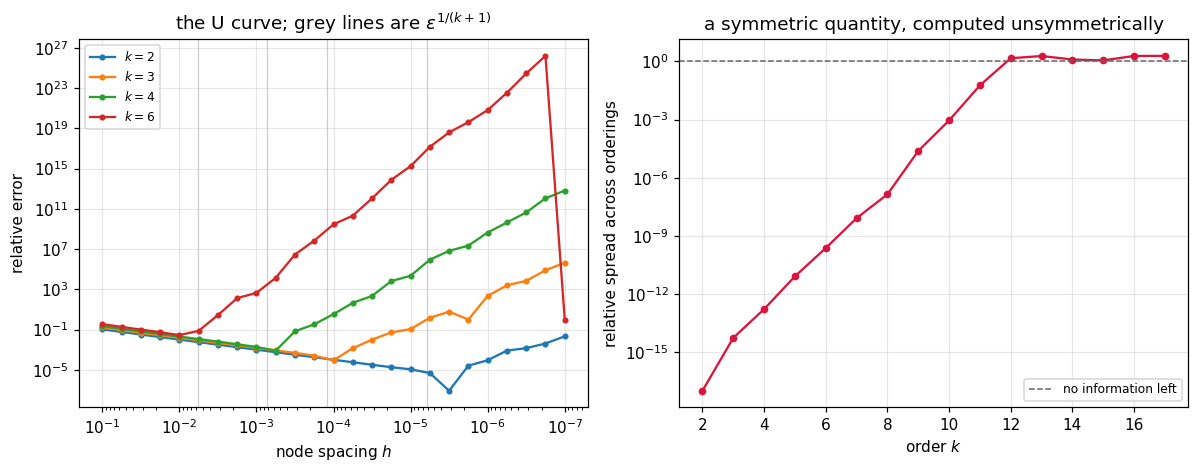

In [11]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

# left: the U curve, truncation against rounding
orders = (2, 3, 4, 6)
spacings = np.geomspace(1e-1, 1e-7, 25)
for k in orders:
    errs = []
    for h in spacings:
        xs = h * np.arange(k + 1)
        v = float(dd.coefficients(xs, np.exp(xs))[-1])
        target = 1.0 / math.factorial(k)
        errs.append(abs(v - target) / target)
    ax_left.loglog(spacings, errs, "o-", ms=3, label=f"$k = {k}$")
    ax_left.axvline(np.finfo(float).eps ** (1.0 / (k + 1)), color="0.8", lw=0.8, zorder=0)
ax_left.set_xlabel("node spacing $h$")
ax_left.set_ylabel("relative error")
ax_left.set_title(r"the U curve; grey lines are $\varepsilon^{1/(k+1)}$")
ax_left.invert_xaxis()
ax_left.legend(fontsize=8)

# right: symmetry lost with order
ks, spreads = [], []
for n in range(3, 19):
    xs = np.linspace(0.0, 1.0, n)
    out = dd.symmetry_report(xs, np.exp(xs), n_orders=20, rng=np.random.default_rng(7))
    ks.append(n - 1)
    spreads.append(max(out["relative_spread"], 1e-17))
ax_right.semilogy(ks, spreads, "o-", ms=4, color="crimson")
ax_right.axhline(1.0, color="0.4", ls="--", lw=1.0, label="no information left")
ax_right.set_xlabel("order $k$")
ax_right.set_ylabel("relative spread across orderings")
ax_right.set_title("a symmetric quantity, computed unsymmetrically")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is a fact about one divided difference and the right panel is a fact about a whole
table, and they are the same fact: dividing by small differences repeatedly cannot be done
accurately, and how badly depends on how many times.

## 9. Exercises

**Level 1, conceptual**

1.1 The value of a divided difference is symmetric in its arguments and the recursion that
computes it is not. Say what that mismatch costs, and at roughly what order it starts to matter.

1.2 A divided difference table is computed and the $k$-th column is constant. What does that tell
you about the data, and what does it tell you about the nodes?

1.3 Explain why $f[x, x] = f'(x)$ is not a separate definition but a limit, and say what has to be
true of $f$ for it to hold.

**Level 2, mathematical**

2.1 Prove the divided difference recursion, by showing both sides are the leading coefficient of
the same interpolating polynomial.

2.2 Prove the closed form $f[x_0,\dots,x_k] = \sum_i f(x_i)/\prod_{j\ne i}(x_i - x_j)$, and use
it to prove symmetry in one line.

2.3 Prove $f[x_0, \dots, x_k] = f^{(k)}(\xi)/k!$ for some $\xi$ in the interval, using Rolle's
theorem on the error of the interpolating polynomial.

2.4 Derive the confluent limit $f[x,\dots,x] = f^{(k)}(x)/k!$ and state exactly what smoothness
it needs.

2.5 Derive the optimal node spacing $h \approx \varepsilon^{1/(k+1)}$ by balancing a truncation
error of $O(h)$ against a rounding error of $O(\varepsilon/h^k)$, and say what changes if the
truncation is $O(h^2)$.

**Level 3, computational**

3.1 Implement divided differences for **repeated nodes** in full generality, so that a node
repeated $m$ times uses the first $m-1$ derivatives, and check it against both the Lagrange and
the Taylor special cases.

3.2 Implement a **compensated** divided difference table using the summation ideas of lesson 3,
and measure how far it pushes the order at which symmetry fails.

3.3 Implement an **adaptive interpolation** routine that adds nodes until a tolerance is met,
using the Newton form's cheap update, and measure the total work against rebuilding each time.

**Level 4, experimental**

4.1 Measure the order at which symmetry fails against the node spacing and against the interval
length, and determine which of the two actually controls it.

4.2 Measure the optimal spacing for each order $k$ and fit the exponent, comparing against
$\varepsilon^{1/(k+1)}$.

4.3 Measure the divided difference of a function with a nearly singular derivative and find where
the derivative connection stops being a useful predictor.

**Level 5, advanced**

5.1 **Divided differences of a matrix function.** $f[A, B]$ makes sense for matrices and appears
in the Frechet derivative of a matrix function. Describe the definition, and say what changes when
the arguments do not commute.

5.2 **The contour integral form.** $f[x_0,\dots,x_k]$ has an integral representation over a
contour enclosing the nodes. State it, and explain what it says about analytic $f$ that the
recursion does not.

5.3 **Why the table cannot be stabilised.** The loss in section 3 is not an artifact of one
implementation. Argue that any algorithm computing a high order divided difference from function
values alone must lose accuracy, and identify what extra information would be needed to avoid it.

## 10. Key takeaways

- **The recursion, the closed form and the naive evaluation agree**, which is what makes any one
  of them trustworthy.

- **Four properties**: symmetric in the arguments, equal to the leading coefficient of the
  interpolating polynomial, linear in the data, and equal to $f^{(k)}(\xi)/k!$ for some interior
  $\xi$. All four were checked numerically.

- **Symmetry fails in floating point at about order 10.** Measured on equally spaced nodes with
  $f = \exp$: a relative spread across orderings of $1.6\times10^{-13}$ at order 4,
  $9.0\times10^{-4}$ at order 10, and **1.91 at order 13**.

- **The error is a U curve** with truncation $O(h)$ and rounding $O(\varepsilon/h^k)$, so the best
  spacing is $\varepsilon^{1/(k+1)}$. Predicted and measured agree at every order tested.

- **The confluent limit is the Taylor coefficient**, so Taylor expansion and interpolation are one
  construction with the spacing as the parameter. Lesson 50 uses that directly.

- **The reason to use them anyway** is the $O(n)$ update. Adding a point to a Newton interpolant
  costs $n$ operations against $n^2$ to rebuild a Lagrange one, and disturbs nothing.

## Where this goes next

Lesson 46 uses the derivative connection to derive the interpolation error formula, and then
shows the error can grow without bound. Lesson 48 specialises the whole table to equally spaced
nodes, where the divisions become exact powers of $h$. Lesson 50 uses the confluent limit to
build Hermite interpolation. Part 9 meets the U curve again, as the central fact of numerical
differentiation.